# GDS surface-trap locator

Import flat GDS electrodes and add SiO2, silicon and locally refined air. Air has the same lateral bounds as the chip. RF is boundary 53 in the completed geometry; the other imported electrodes are grounded.

Run the cells in order. RF is assigned after building the stack. Mesh and solve are separate cells; run them when ready. Restart from the first cell when changing geometry.

The later search locates an RF-field minimum; DC confinement is not included.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mph
from jpype import JArray
from jpype.types import JBoolean, JDouble, JInt

# In a notebook cell, install into this exact kernel with: %pip install MPh
client = mph.start(version='6.1')
model = client.create('gds_surface_trap_locator')
j = model.java
print('COMSOL version:', client.version)

COMSOL version: 6.1


## 1. Configuration

Set the GDS path, exact cell name and layer. `RF_FACE_IDS = [53]` selects RF in the completed geometry. Lengths are in micrometers.


In [2]:
# ---------- GDS input ----------
GDS_FILE = Path(r"C:\Users\Administrator\Downloads\comsol_trap_rf.gds")
GDS_CELL = 'TRAP'       # Use '' to import the GDS top cell
ELECTRODE_LAYER = 'LAYER7'
ELECTRODE_Z_UM = 0.0

RF_FACE_IDS = [53]  # Boundary IDs in the completed geometry

# ---------- Dielectric stack ----------
OXIDE_THICKNESS_UM = 12.0
SILICON_THICKNESS_UM = 675.0
EPSR_SIO2 = 3.9
EPSR_SILICON = 11.7

# None derives the chip footprint from the GDS bounding box plus this margin.
# Alternatively provide [xmin, xmax, ymin, ymax] explicitly.
CHIP_BOUNDS_XY_UM = None
CHIP_EDGE_MARGIN_UM = 50.0
AIR_Z_MAX_UM = 1000.0

# ---------- Local refinement and local RF-null search ----------
TRAP_POINT_GUESS_UM = np.array([0, 0, 75.0], dtype=float)
LOCAL_SPHERE_RADIUS_UM = 50.0
SEARCH_HALF_WIDTH_UM = np.array([0.0, 10.0, 18.0], dtype=float)  # Fix x at the initial guess
SEARCH_GRID_SHAPE = (1, 17, 25)  # Search only y and z; axial confinement is not set
SEARCH_REFINEMENT_STAGES = 4
SEARCH_SHRINK_FACTOR = 0.25
INTERPOLATION_BATCH_SIZE = 2000
CURVATURE_STEP_UM = 1.0  # Central-difference step for RF-only frequencies

# ---------- Mesh sizes: hmax, hmin, maximum growth rate ----------
LOCAL_MESH = {'hmax': 1.0, 'hmin': 0.5, 'growth': 1.25}
RF_SURFACE_MESH = {'hmax': 20.0, 'hmin': 1.0, 'growth': 1.45}
GND_SURFACE_MESH = {'hmax': 50.0, 'hmin': 3.0, 'growth': 1.60}
OXIDE_MESH = {'hmax': 100.0, 'hmin': 8.0, 'growth': 1.65}
SILICON_MESH = {'hmax': 400.0, 'hmin': 30.0, 'growth': 1.80}
BULK_AIR_MESH = {'hmax': 400.0, 'hmin': 20.0, 'growth': 1.80}
OXIDE_SWEEP_LAYERS = 4

# RF pseudopotential reporting. RF_VOLTAGE_V is the peak, not RMS, amplitude.
RF_VOLTAGE_V = 100.0
RF_FREQUENCY_HZ = 40e6
ION_MASS_AMU = 40.0
ION_CHARGE_E = 1.0

GDS_FILE = GDS_FILE.resolve()


## 2. Import the selected GDS layer as zero-thickness faces

`importtype='shell'` is the important setting: the GDS polygons become faces at `z=0`, not metal volumes. Layer selections are requested so the final electrode faces can be recovered after Form Union. An ECAD Import Module license is required.

In [3]:
j.component().create('comp1', JBoolean(True))
comp = j.component('comp1')
comp.geom().create('geom1', 3)
geom = comp.geom('geom1')

geom.create('imp1', 'Import')
imp = geom.feature('imp1')
imp.label('Zero-thickness GDS surface electrodes')
imp.set('filename', str(GDS_FILE))
imp.set('updategeomunit', JBoolean(True))
imp.set('grouping', 'layer')
imp.set('importtype', 'shell')
imp.set('manualelevation', 'on')
imp.set('intbnd', 'on')
imp.set('findarcs', 'auto')
imp.set('repairgeom', 'on')
imp.set('repairtoltype', 'auto')
imp.set('selresult', 'on')
imp.set('selresultshow', 'all')
imp.set('sellayer', 'on')
imp.set('sellayershow', 'all')

if GDS_CELL:
    imp.set('cell', GDS_CELL)
layer_table = np.asarray(imp.getStringMatrix('layerprop'), dtype=object)

layer_names = [str(row[0]).upper() for row in layer_table]
wanted_layer = ELECTRODE_LAYER.upper()
import_flags = ['on' if name == wanted_layer else 'off' for name in layer_names]
imp.set('importlayer', import_flags)
imp.set('elevation', [
    f'{ELECTRODE_Z_UM}[um]' if flag == 'on' else '0[um]'
    for flag in import_flags
])

imp.importData()
geom.run('imp1')

imported_objects = list(imp.objectNames())
import_measure = geom.measure()
import_measure.selection().set(imported_objects)
electrode_bbox = np.asarray(import_measure.getBoundingBox(), dtype=float)
exmin, exmax, eymin, eymax, ezmin, ezmax = electrode_bbox
print('Geometry unit:', geom.lengthUnit())
print('Imported electrode bounding box [um]:', electrode_bbox)

geom.run()


Geometry unit: µm
Imported electrode bounding box [um]: [-5500.  6000. -3250.  3250.     0.     0.]


## 3. Build SiO2, silicon, bulk air, and the fine spherical air domain

The oxide top is exactly coincident with the zero-thickness GDS faces. The solid sphere is subtracted from the bulk-air block while `keepsubtract='on'` preserves it as a separate air domain. This geometric partition is what confines the very fine tetrahedral mesh to a small volume. Air is modeled above the chip; the distant chip sides and silicon bottom retain the default zero-charge condition.

In [4]:
if CHIP_BOUNDS_XY_UM is None:
    chip_xmin = exmin-CHIP_EDGE_MARGIN_UM
    chip_xmax = exmax+CHIP_EDGE_MARGIN_UM
    chip_ymin = eymin-CHIP_EDGE_MARGIN_UM
    chip_ymax = eymax+CHIP_EDGE_MARGIN_UM
else:
    chip_xmin, chip_xmax, chip_ymin, chip_ymax = map(float, CHIP_BOUNDS_XY_UM)

chip_length = chip_xmax-chip_xmin
chip_width = chip_ymax-chip_ymin
oxide_zmin = ELECTRODE_Z_UM-OXIDE_THICKNESS_UM
silicon_zmax = oxide_zmin
silicon_zmin = silicon_zmax-SILICON_THICKNESS_UM

def add_block(tag, label, position_um, size_um):
    geom.create(tag, 'Block')
    block = geom.feature(tag)
    block.label(label)
    block.set('base', 'corner')
    block.set('pos', [f'{v:.12g}' for v in position_um])
    block.set('size', [f'{v:.12g}' for v in size_um])
    block.set('selresult', 'on')
    block.set('selresultshow', 'all')
    return block

add_block('oxide', f'{OXIDE_THICKNESS_UM:g} um SiO2',
          [chip_xmin, chip_ymin, oxide_zmin],
          [chip_length, chip_width, OXIDE_THICKNESS_UM])
add_block('silicon', f'{SILICON_THICKNESS_UM:g} um silicon',
          [chip_xmin, chip_ymin, silicon_zmin],
          [chip_length, chip_width, SILICON_THICKNESS_UM])
add_block('air_box', 'Upper bulk-air box',
          [chip_xmin, chip_ymin, ELECTRODE_Z_UM],
          [chip_length, chip_width, AIR_Z_MAX_UM-ELECTRODE_Z_UM])

geom.create('trap_ball', 'Sphere')
trap_ball = geom.feature('trap_ball')
trap_ball.label('Fine air sphere around trap-point guess')
trap_ball.set('pos', [f'{v:.12g}' for v in TRAP_POINT_GUESS_UM])
trap_ball.set('r', f'{LOCAL_SPHERE_RADIUS_UM:.12g}')
trap_ball.set('selresult', 'on')
trap_ball.set('selresultshow', 'all')

geom.create('dif_air_outer', 'Difference')
dif_air_outer = geom.feature('dif_air_outer')
dif_air_outer.label('Bulk air minus fine sphere')
dif_air_outer.selection('input').set(['air_box'])
dif_air_outer.selection('input2').set(['trap_ball'])
dif_air_outer.set('keepsubtract', 'on')
dif_air_outer.set('intbnd', 'on')
dif_air_outer.set('selresult', 'on')
dif_air_outer.set('selresultshow', 'all')

# Form Union imprints the GDS shell faces into the air/oxide interface.
geom.feature('fin').set('action', 'union')
geom.run()
final_bbox = np.asarray(geom.getBoundingBox(), dtype=float)
print('Chip xy bounds [um]:', [chip_xmin, chip_xmax, chip_ymin, chip_ymax])
print('Oxide z bounds [um]:', [oxide_zmin, ELECTRODE_Z_UM])
print('Silicon z bounds [um]:', [silicon_zmin, silicon_zmax])
print('Final geometry bounding box [um]:', final_bbox)


Chip xy bounds [um]: [np.float64(-5550.000000000001), np.float64(6050.0), np.float64(-3300.000000000001), np.float64(3300.000000000001)]
Oxide z bounds [um]: [-12.0, 0.0]
Silicon z bounds [um]: [-687.0, -12.0]
Final geometry bounding box [um]: [-5550.  6050. -3300.  3300.  -687.  1000.]


## 4. RF, GND and material selections

RF is final boundary 53. GND contains every other imported electrode face. Domain selections assign materials; the oxide top and bottom selections define its swept mesh.


In [5]:
def selection_ids(tag, dimension):
    return sorted(int(v) for v in comp.selection(tag).entities(JInt(dimension)))

electrode_face_ids = selection_ids('geom1_imp1_bnd', 2)
outer_air_ids = selection_ids('geom1_dif_air_outer_dom', 3)
local_air_ids = selection_ids('geom1_trap_ball_dom', 3)
oxide_ids = selection_ids('geom1_oxide_dom', 3)
silicon_ids = selection_ids('geom1_silicon_dom', 3)
air_ids = sorted(set(outer_air_ids + local_air_ids))
dielectric_ids = sorted(set(air_ids + oxide_ids + silicon_ids))

rf_face_ids = RF_FACE_IDS
gnd_face_ids = sorted(set(electrode_face_ids) - set(rf_face_ids))

# Measure horizontal oxide faces for the swept mesh.
face_measure = comp.measure()
face_measure.selection().geom('geom1', JInt(2))

def boundary_bbox(face_id):
    face_measure.selection().set(JArray(JInt)([int(face_id)]))
    return np.asarray(face_measure.getBoundingBox(), dtype=float)

def horizontal_faces(domain_ids, z_um):
    boundaries = set()
    for domain_id in domain_ids:
        boundaries.update(int(v) for v in geom.getAdj(
            JInt(3), JInt(2), JInt(domain_id)))
    return sorted(face_id for face_id in boundaries
                  if np.allclose(boundary_bbox(face_id)[4:], z_um,
                                 rtol=0, atol=1e-6))

oxide_top_faces = horizontal_faces(oxide_ids, ELECTRODE_Z_UM)
oxide_bottom_faces = horizontal_faces(oxide_ids, oxide_zmin)

def explicit_selection(tag, label, dimension, entity_ids):
    if tag in [str(t) for t in comp.selection().tags()]:
        comp.selection().remove(tag)
    selection = comp.selection().create(tag, 'Explicit')
    selection.label(label)
    selection.geom('geom1', JInt(dimension))
    selection.set(JArray(JInt)(list(entity_ids)))
    return selection

for tag, ids in [
    ('AIR_OUTER', outer_air_ids), ('AIR_LOCAL', local_air_ids),
    ('AIR', air_ids), ('SIO2', oxide_ids), ('SILICON', silicon_ids),
    ('DIELECTRICS', dielectric_ids),
]:
    explicit_selection(tag, tag, 3, ids)

for tag, ids in [
    ('RF', rf_face_ids), ('GND', gnd_face_ids),
    ('OXIDE_SOURCE', oxide_top_faces), ('OXIDE_TARGET', oxide_bottom_faces),
]:
    explicit_selection(tag, tag, 2, ids)

print('RF faces in completed geometry:', rf_face_ids)
print('GND faces in completed geometry:', gnd_face_ids)


RF faces in completed geometry: [53]
GND faces in completed geometry: [14, 15, 18, 19, 21, 24, 27, 29, 31, 33, 34, 38, 39, 41, 42, 43, 46, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 74, 75, 76, 77, 78, 81, 82, 85, 88, 91, 93]


## 5. Materials and Electrostatics

Only air, SiO2, and silicon are solved as domains. The zero-thickness conductors are boundary conditions: RF is a voltage terminal and every remaining imported face is ground. This avoids meshing any metal thickness.

In [6]:
def add_isotropic_material(tag, label, epsr, selection_tag):
    material = comp.material().create(tag, 'Common')
    material.label(label)
    material.selection().named(selection_tag)
    tensor = [
        str(epsr), '0', '0',
        '0', str(epsr), '0',
        '0', '0', str(epsr),
    ]
    material.propertyGroup('def').set('relpermittivity', tensor)
    return material

add_isotropic_material('mat_air', 'Air', 1.0, 'AIR')
add_isotropic_material('mat_sio2', 'SiO2', EPSR_SIO2, 'SIO2')
add_isotropic_material('mat_silicon', 'Silicon (dielectric)',
                       EPSR_SILICON, 'SILICON')

j.param().set('Vrf', f'{RF_VOLTAGE_V:.12g}[V]', 'Peak RF voltage amplitude')
comp.physics().create('es', 'Electrostatics', 'geom1')
es = comp.physics('es')
es.selection().named('DIELECTRICS')
es.feature('ccn1').label('Charge Conservation: AIR + SIO2 + Silicon')

es.create('gnd1', 'Ground', JInt(2))
es.feature('gnd1').label('All non-RF surface electrodes: 0 V')
es.feature('gnd1').selection().named('GND')

es.create('term1', 'Terminal', JInt(2))
terminal = es.feature('term1')
terminal.label('Zero-thickness RF terminal')
terminal.selection().named('RF')
terminal.set('TerminalType', 'Voltage')
terminal.set('TerminalName', '1')
terminal.set('V0', 'Vrf')
print('Electrostatics configured: RF =', RF_VOLTAGE_V, 'V peak; all other faces grounded.')


Electrostatics configured: RF = 100.0 V peak; all other faces grounded.


## 6. Mesh and stationary study

The sequence first triangulates the GDS-partitioned oxide surface and sweeps that mesh through the thin oxide. Silicon is filled coarsely. The spherical air domain is tetrahedralized at 0.5--1 um before the outer air is filled, forcing the outer mesh to conform to the sphere while allowing it to grow rapidly away from the trap region. This topology avoids applying the fine size to the entire air box.

In [7]:
comp.mesh().create('mesh1')
mesh = comp.mesh('mesh1')
mesh.label('Local fine sphere with coarse dielectric and air bulk')

def add_mesh_size(parent, tag, label, selection_tag, settings):
    parent.create(tag, 'Size')
    size = parent.feature(tag)
    size.label(label)
    size.selection().named(selection_tag)
    size.set('custom', JBoolean(True))
    size.set('hmax', f"{settings['hmax']}[um]")
    size.set('hmin', f"{settings['hmin']}[um]")
    size.set('hgrad', str(settings['growth']))
    return size

# 1. Mesh the complete oxide top, including every GDS partition.
mesh.create('ftri_surface', 'FreeTri')
ftri_surface = mesh.feature('ftri_surface')
ftri_surface.label('01 | Triangular mesh on electrode/oxide surface')
ftri_surface.selection().named('OXIDE_SOURCE')
add_mesh_size(ftri_surface, 'size_oxide', 'Exposed oxide surface',
              'OXIDE_SOURCE', OXIDE_MESH)
add_mesh_size(ftri_surface, 'size_gnd', 'Zero-thickness GND faces',
              'GND', GND_SURFACE_MESH)
add_mesh_size(ftri_surface, 'size_rf', 'Zero-thickness RF faces',
              'RF', RF_SURFACE_MESH)

# 2. Sweep through SiO2; no thin tetrahedral layer is created.
mesh.create('swe_oxide', 'Sweep')
swe_oxide = mesh.feature('swe_oxide')
swe_oxide.label(f'02 | Sweep {OXIDE_THICKNESS_UM:g} um SiO2')
swe_oxide.selection().named('SIO2')
swe_oxide.selection('sourceface').named('OXIDE_SOURCE')
swe_oxide.selection('targetface').named('OXIDE_TARGET')
swe_oxide.set('facemethod', 'tri')
swe_oxide.set('sweeppath', 'straight')
add_mesh_size(swe_oxide, 'size1', 'SiO2 lateral size', 'SIO2', OXIDE_MESH)
swe_oxide.create('dist1', 'Distribution')
swe_oxide.feature('dist1').label(f'{OXIDE_SWEEP_LAYERS} elements through SiO2')
swe_oxide.feature('dist1').selection().named('SIO2')
swe_oxide.feature('dist1').set('numelem', JInt(OXIDE_SWEEP_LAYERS))

# 3. Coarse silicon bulk.
mesh.create('ftet_silicon', 'FreeTet')
ftet_silicon = mesh.feature('ftet_silicon')
ftet_silicon.label('03 | Free tetrahedra in silicon')
ftet_silicon.selection().named('SILICON')
add_mesh_size(ftet_silicon, 'size1', 'Coarse silicon bulk',
              'SILICON', SILICON_MESH)

# 4. Fine spherical air first. Its radius bounds the expensive mesh volume.
mesh.create('ftet_local_air', 'FreeTet')
ftet_local_air = mesh.feature('ftet_local_air')
ftet_local_air.label('04 | Fine tetrahedra in trap-point sphere')
ftet_local_air.selection().named('AIR_LOCAL')
add_mesh_size(ftet_local_air, 'size1', 'Trap sphere: 1/0.5 um',
              'AIR_LOCAL', LOCAL_MESH)

# 5. Fill outer air last so it inherits the fine spherical interface mesh.
mesh.create('ftet_outer_air', 'FreeTet')
ftet_outer_air = mesh.feature('ftet_outer_air')
ftet_outer_air.label('05 | Coarse tetrahedra in remaining upper air')
ftet_outer_air.selection().named('AIR_OUTER')
add_mesh_size(ftet_outer_air, 'size_bulk', 'Coarse outer air',
              'AIR_OUTER', BULK_AIR_MESH)
add_mesh_size(ftet_outer_air, 'size_gnd', 'GND-facing air mesh',
              'GND', GND_SURFACE_MESH)
add_mesh_size(ftet_outer_air, 'size_rf', 'RF-facing air mesh',
              'RF', RF_SURFACE_MESH)

j.study().create('std1')
j.study('std1').label('Stationary RF basis-potential study')
j.study('std1').create('stat', 'Stationary')
print('Mesh and stationary study configured.')
print('Fine local sphere:', LOCAL_MESH, 'radius =', LOCAL_SPHERE_RADIUS_UM, 'um')
print('Bulk air:', BULK_AIR_MESH)
print('No mesh, solve, or save operation has run yet.')


Mesh and stationary study configured.
Fine local sphere: {'hmax': 1.0, 'hmin': 0.5, 'growth': 1.25} radius = 50.0 um
Bulk air: {'hmax': 400.0, 'hmin': 20.0, 'growth': 1.8}
No mesh, solve, or save operation has run yet.


## 7. Build and inspect the mesh

Run this cell deliberately. It builds the mesh but does not solve or save. In COMSOL Desktop, verify that the dense region is a small sphere around the supplied coordinate and that the remainder expands smoothly.

In [8]:
repo_output_dir = Path.cwd() / 'Simulations' / 'rf'
output_dir = repo_output_dir if repo_output_dir.is_dir() else Path.cwd()
setup_file = (
    output_dir / 'rf.mph'
)
model.save(str(setup_file))

In [9]:
print('Building mesh; the model remains in memory and is not being saved...')
mesh.run()
print('Mesh build completed. Inspect Mesh 1 in COMSOL before solving.')


Building mesh; the model remains in memory and is not being saved...
Mesh build completed. Inspect Mesh 1 in COMSOL before solving.


## 8. Solve the stationary RF basis field

This is one electrostatic solve with RF at the configured peak voltage and every other imported electrode at ground. It creates the solution dataset used by the local search. It does not save the model.

In [10]:
print('Running stationary Electrostatics study...')
j.study('std1').run()
dataset_tags = [str(tag) for tag in j.result().dataset().tags()]
SOLUTION_DATASET = 'dset1'
print('Solve completed. Available datasets:', dataset_tags)


Running stationary Electrostatics study...
Solve completed. Available datasets: ['dset1']


## 9. Locate the local RF-field null

The search evaluates `es.normE` on a bounded YZ grid at fixed x = `TRAP_POINT_GUESS_UM[0]`, keeps the lowest-field point, shrinks the box, and repeats. It never searches the entire air domain, where the field naturally approaches zero far from the electrodes. If a minimum lies on a search-box edge, broaden or move the initial box before trusting the result. Coordinates passed to COMSOL are in the geometry unit (um), while `es.normE` is returned in V/m. A central-difference electric-field Jacobian is also calculated at the candidate; its singular values give the three RF-only small-amplitude secular-frequency estimates. A weak or zero axial value is expected when DC confinement is absent.

In [11]:
INTERP_TAG = 'interp_trap_search'
numerical_tags = [str(tag) for tag in j.result().numerical().tags()]
if INTERP_TAG in numerical_tags:
    j.result().numerical().remove(INTERP_TAG)
j.result().numerical().create(INTERP_TAG, 'Interp')
interp = j.result().numerical(INTERP_TAG)
interp.label('Batched interpolation near RF null')
interp.set('data', SOLUTION_DATASET)
interp.set('coorderr', 'on')

def interpolate_scalar(expression, points_um, unit):
    points_um = np.asarray(points_um, dtype=float)
    interp.set('expr', [expression])
    interp.set('unit', [unit])
    values = np.full(points_um.shape[1], np.nan, dtype=float)
    for start in range(0, points_um.shape[1], INTERPOLATION_BATCH_SIZE):
        stop = min(start+INTERPOLATION_BATCH_SIZE, points_um.shape[1])
        interp.setInterpolationCoordinates(
            JArray(JDouble, 2)(points_um[:, start:stop].tolist())
        )
        interp.run()
        raw = np.asarray(interp.getData(0), dtype=float).squeeze().reshape(-1)
        values[start:stop] = raw
    return values

def search_axis(center, half_width, count):
    if half_width == 0 or count == 1:
        return np.array([center], dtype=float)
    return np.linspace(center-half_width, center+half_width, int(count))

search_center = TRAP_POINT_GUESS_UM.astype(float).copy()
half_width = SEARCH_HALF_WIDTH_UM.astype(float).copy()
search_history = []
for stage in range(SEARCH_REFINEMENT_STAGES):
    axes = [search_axis(search_center[i], half_width[i], SEARCH_GRID_SHAPE[i])
            for i in range(3)]
    X, Y, Z = np.meshgrid(*axes, indexing='ij')
    points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    E_values = interpolate_scalar('es.normE', points, 'V/m')
    E_grid = E_values.reshape(X.shape)
    minimum_index = np.unravel_index(np.nanargmin(E_grid), E_grid.shape)
    new_center = np.array([axes[i][minimum_index[i]] for i in range(3)])
    minimum_field = float(E_grid[minimum_index])
    edge_axes = [
        axis_name for axis_name, index, count in zip('xyz', minimum_index, E_grid.shape)
        if count > 1 and index in (0, count-1)
    ]
    search_history.append((stage+1, new_center.copy(), minimum_field, edge_axes))
    print(
        f'Stage {stage+1}: point={new_center} um, |E|={minimum_field:.6g} V/m, '
        f'edge axes={edge_axes or "none"}'
    )
    search_center = new_center
    half_width *= SEARCH_SHRINK_FACTOR

TRAP_LOCATION_UM = search_center
distance_from_sphere_center = np.linalg.norm(
    TRAP_LOCATION_UM-TRAP_POINT_GUESS_UM
)
point_column = TRAP_LOCATION_UM.reshape(3, 1)
V_trap = interpolate_scalar('V', point_column, 'V')[0]
Ex = interpolate_scalar('es.Ex', point_column, 'V/m')[0]
Ey = interpolate_scalar('es.Ey', point_column, 'V/m')[0]
Ez = interpolate_scalar('es.Ez', point_column, 'V/m')[0]
E_trap = float(np.linalg.norm([Ex, Ey, Ez]))

ELEMENTARY_CHARGE_C = 1.602176634e-19
ATOMIC_MASS_KG = 1.66053906660e-27
ion_charge = ION_CHARGE_E*ELEMENTARY_CHARGE_C
ion_mass = ION_MASS_AMU*ATOMIC_MASS_KG
omega_rf = 2*np.pi*RF_FREQUENCY_HZ
pseudopotential_J = ion_charge**2*E_trap**2/(4*ion_mass*omega_rf**2)
pseudopotential_eV = pseudopotential_J/ELEMENTARY_CHARGE_C

# RF-only local curvature. Near an RF null, Hessian(Psi) is proportional
# to J_E.T @ J_E, where J_E is the spatial electric-field Jacobian.
def field_vector_at(point_um):
    point = np.asarray(point_um, dtype=float).reshape(3, 1)
    return np.array([
        interpolate_scalar('es.Ex', point, 'V/m')[0],
        interpolate_scalar('es.Ey', point, 'V/m')[0],
        interpolate_scalar('es.Ez', point, 'V/m')[0],
    ])

field_jacobian = np.zeros((3, 3), dtype=float)
step_m = CURVATURE_STEP_UM*1e-6
for axis in range(3):
    offset_um = np.zeros(3)
    offset_um[axis] = CURVATURE_STEP_UM
    field_plus = field_vector_at(TRAP_LOCATION_UM+offset_um)
    field_minus = field_vector_at(TRAP_LOCATION_UM-offset_um)
    field_jacobian[:, axis] = (field_plus-field_minus)/(2*step_m)
jacobian_singular_values = np.linalg.svd(field_jacobian, compute_uv=False)
rf_secular_angular_frequencies = np.sort(
    abs(ion_charge)*jacobian_singular_values
    /(np.sqrt(2)*ion_mass*omega_rf)
)
rf_secular_frequencies_hz = rf_secular_angular_frequencies/(2*np.pi)

print('\nRF-null candidate [um]:', TRAP_LOCATION_UM)
print(f'Displacement from guess: {distance_from_sphere_center:.6g} um')
print(f'Potential V: {V_trap:.9g} V')
print(f'Electric field [V/m]: Ex={Ex:.9g}, Ey={Ey:.9g}, Ez={Ez:.9g}')
print(f'|E|: {E_trap:.9g} V/m')
print(f'RF pseudopotential at candidate: {pseudopotential_eV:.9g} eV')
print('RF-only secular-frequency estimates [MHz]:',
      rf_secular_frequencies_hz/1e6)
print('Electric-field Jacobian [V/m^2]:\n', field_jacobian)
print('Interpret this as an RF-null candidate; DC confinement is not included.')


Stage 1: point=[ 0.    3.75 76.5 ] um, |E|=3288.04 V/m, edge axes=none
Stage 2: point=[ 0.      3.4375 75.75  ] um, |E|=658.932 V/m, edge axes=none
Stage 3: point=[ 0.        3.515625 75.84375 ] um, |E|=69.4066 V/m, edge axes=none
Stage 4: point=[ 0.         3.515625  75.8671875] um, |E|=47.2688 V/m, edge axes=none

RF-null candidate [um]: [ 0.         3.515625  75.8671875]
Displacement from guess: 3.621 um
Potential V: 34.9187531 V
Electric field [V/m]: Ex=1.17913672, Ey=17.04451, Ez=44.073043
|E|: 47.2687931 V/m
RF pseudopotential at candidate: 2.13309708e-08 eV
RF-only secular-frequency estimates [MHz]: [9.51642528e-04 5.25338016e+00 5.26452232e+00]
Electric-field Jacobian [V/m^2]:
 [[-8.87137913e+05 -4.15379188e+06 -5.99322120e+06]
 [-2.12199245e+06 -4.82353340e+09  6.95487698e+08]
 [ 3.46850911e+06  6.89202003e+08  4.81534572e+09]]
Interpret this as an RF-null candidate; DC confinement is not included.


## 10. Plot a YZ pseudopotential slice through the candidate

The plot is generated in memory only. Its logarithmic scale exposes the local minimum without hiding the much larger field away from the null. The white marker is the final candidate and the cyan marker is the original mesh/search center.

The slice is clipped to the upper-air box in y and z so interpolation batches remain inside the solved geometry. Edge candidates and candidates outside the fine mesh sphere are flagged; clipping the plot does not establish that the search found a null.


Plot bounds [um]: y=[-16.4844, 23.5156], z=[50.8672, 100.867] (clipped to upper air)


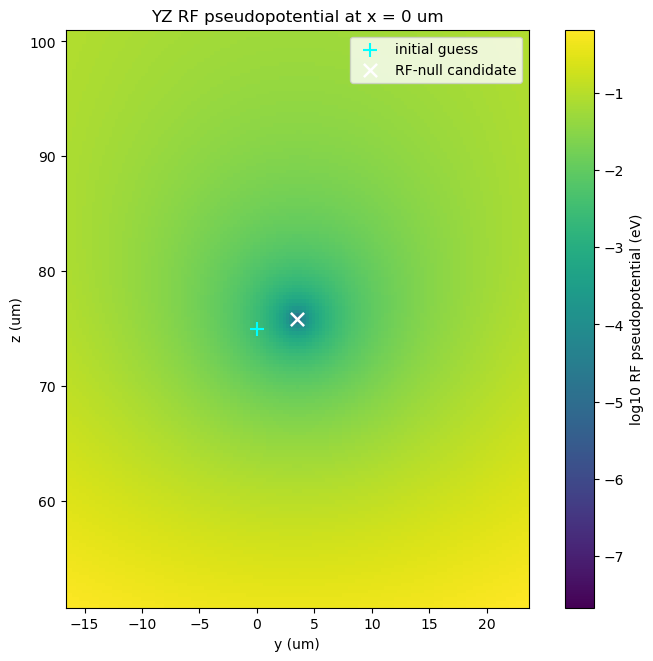

In [12]:
PLOT_Y_HALF_WIDTH_UM = 20.0
PLOT_Z_HALF_WIDTH_UM = 25.0
PLOT_NY = 141
PLOT_NZ = 161

# Stay strictly inside the upper-air box: batches above its top have no
# solution coordinates and COMSOL raises "Undefined post expression".
plot_margin_um = 1e-6
plot_y_min = max(chip_ymin+plot_margin_um,
                 TRAP_LOCATION_UM[1]-PLOT_Y_HALF_WIDTH_UM)
plot_y_max = min(chip_ymax-plot_margin_um,
                 TRAP_LOCATION_UM[1]+PLOT_Y_HALF_WIDTH_UM)
plot_z_min = max(ELECTRODE_Z_UM+plot_margin_um,
                 TRAP_LOCATION_UM[2]-PLOT_Z_HALF_WIDTH_UM)
plot_z_max = min(AIR_Z_MAX_UM-plot_margin_um,
                 TRAP_LOCATION_UM[2]+PLOT_Z_HALF_WIDTH_UM)
if not (chip_xmin < TRAP_LOCATION_UM[0] < chip_xmax
        and plot_y_min < plot_y_max and plot_z_min < plot_z_max):
    raise ValueError('The requested YZ slice does not intersect the upper-air box.')
print(f'Plot bounds [um]: y=[{plot_y_min:g}, {plot_y_max:g}], '
      f'z=[{plot_z_min:g}, {plot_z_max:g}] (clipped to upper air)')
if search_history[-1][3]:
    print('WARNING: candidate is on a search-box edge; the RF null is not confirmed.')
if distance_from_sphere_center >= LOCAL_SPHERE_RADIUS_UM:
    print('WARNING: candidate is outside the fine mesh sphere; '
          'recenter the refinement region and rebuild/solve before trusting curvature.')
plot_y = np.linspace(plot_y_min, plot_y_max, PLOT_NY)
plot_z = np.linspace(plot_z_min, plot_z_max, PLOT_NZ)
Y_plot, Z_plot = np.meshgrid(plot_y, plot_z)
plot_points = np.vstack([
    np.full(Y_plot.size, TRAP_LOCATION_UM[0]),
    Y_plot.ravel(),
    Z_plot.ravel(),
])
E_plot = interpolate_scalar('es.normE', plot_points, 'V/m').reshape(Y_plot.shape)
U_plot_J = ion_charge**2*E_plot**2/(4*ion_mass*omega_rf**2)
U_plot_eV = U_plot_J/ELEMENTARY_CHARGE_C
positive = U_plot_eV[np.isfinite(U_plot_eV) & (U_plot_eV > 0)]
if not np.any(np.isfinite(U_plot_eV)):
    raise ValueError('No finite pseudopotential values in the slice; check the solution dataset and air bounds.')
log_floor = max(float(positive.min()), 1e-18) if positive.size else 1e-18
log_U = np.log10(np.maximum(U_plot_eV, log_floor))

fig, ax = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
image = ax.pcolormesh(Y_plot, Z_plot, log_U, shading='auto', cmap='viridis')
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label('log10 RF pseudopotential (eV)')
ax.scatter(TRAP_POINT_GUESS_UM[1], TRAP_POINT_GUESS_UM[2],
           marker='+', s=100, linewidth=1.5, color='cyan', label='initial guess')
ax.scatter(TRAP_LOCATION_UM[1], TRAP_LOCATION_UM[2],
           marker='x', s=90, linewidth=1.8, color='white', label='RF-null candidate')
ax.set(
    title=f'YZ RF pseudopotential at x = {TRAP_LOCATION_UM[0]:.6g} um',
    xlabel='y (um)', ylabel='z (um)',
)
ax.set_aspect('equal')
ax.legend(loc='best')
plt.show()



## 11. RF contours, signed field cuts, and pseudopotential profiles
Run after the RF-null search. These diagnostics use the existing solution at fixed candidate x and clip sampling to the upper-air box. White arrows show the transverse electric-field direction at positive RF peak; the two cuts pass exactly through the candidate. Pseudopotential includes all three field components and is displayed as absolute energy, without subtracting the candidate value.


Cuts hold the other two coordinates fixed at [ 0.         3.515625  75.8671875] um.
Signed fields are the electrostatic RF peak basis; energy includes Ex, Ey and Ez.


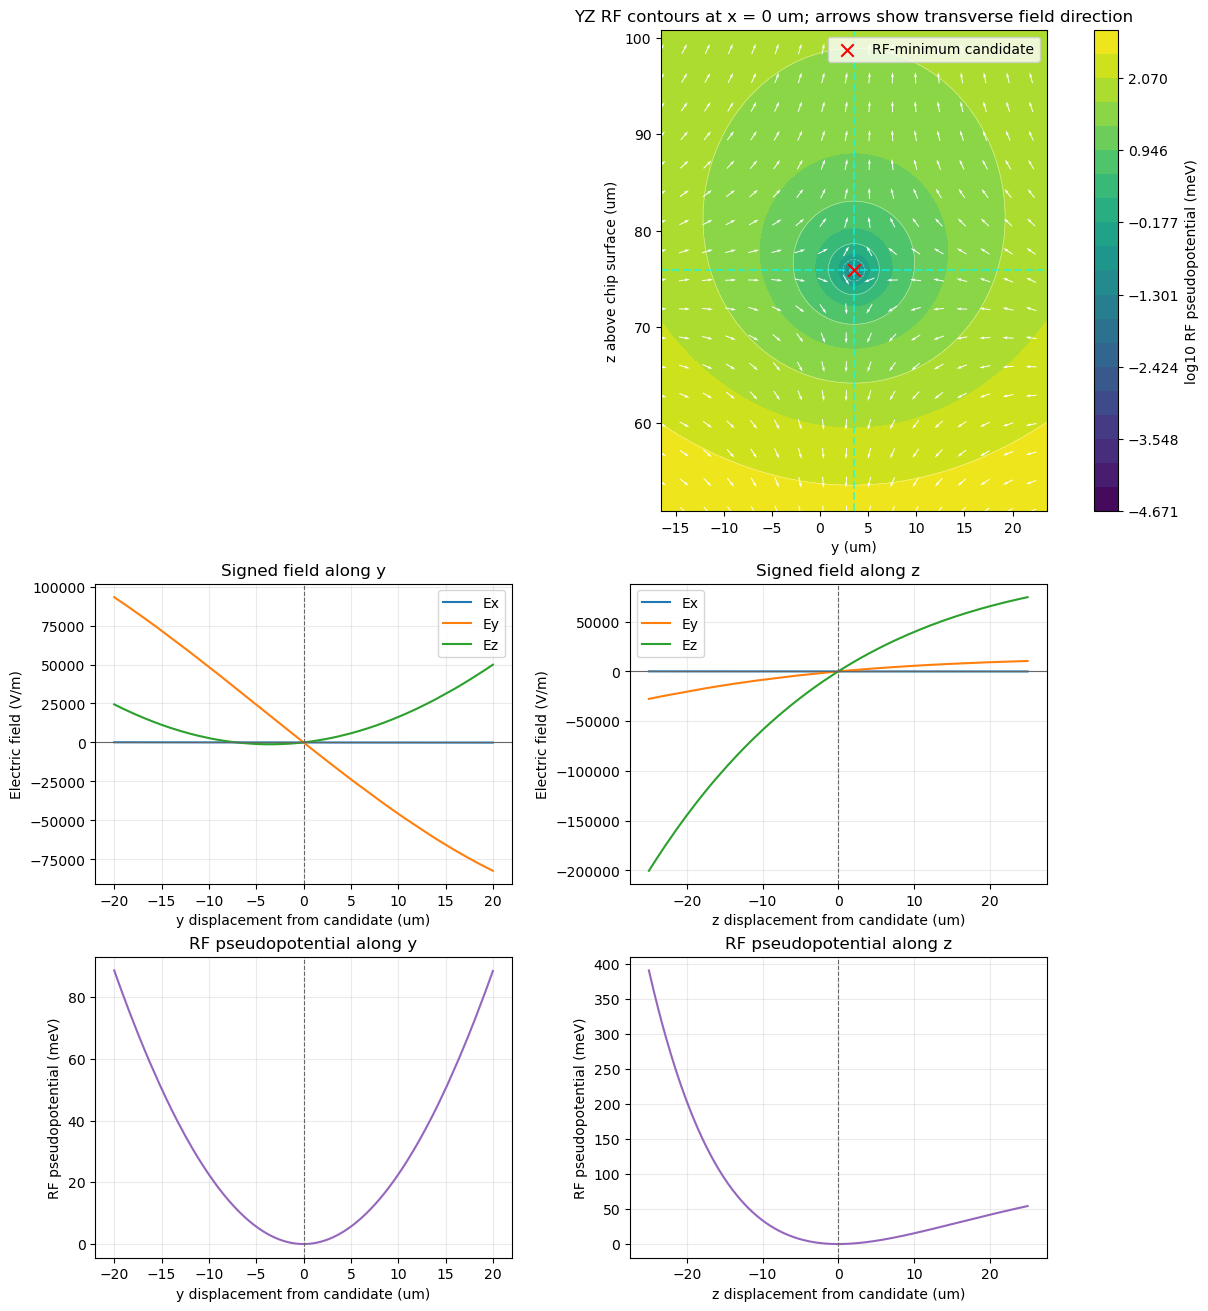

In [13]:
# Run after the RF-null search; the preceding plotting cell is optional.
RF_DIAG_Y_HALF_WIDTH_UM = 20.0
RF_DIAG_Z_HALF_WIDTH_UM = 25.0
RF_DIAG_GRID_N = 101
RF_DIAG_CUT_N = 401


def plot_rf_diagnostics():
    center = np.asarray(TRAP_LOCATION_UM, dtype=float)
    margin = 1e-6
    if not (chip_xmin < center[0] < chip_xmax
            and chip_ymin < center[1] < chip_ymax
            and ELECTRODE_Z_UM < center[2] < AIR_Z_MAX_UM):
        raise ValueError('The candidate must be inside the upper-air box.')
    if min(RF_DIAG_Y_HALF_WIDTH_UM, RF_DIAG_Z_HALF_WIDTH_UM) <= 0:
        raise ValueError('Diagnostic half-widths must be positive.')
    if min(RF_DIAG_GRID_N, RF_DIAG_CUT_N) < 3:
        raise ValueError('Use at least three samples per axis.')
    y_limits = (max(chip_ymin+margin, center[1]-RF_DIAG_Y_HALF_WIDTH_UM),
                min(chip_ymax-margin, center[1]+RF_DIAG_Y_HALF_WIDTH_UM))
    z_limits = (max(ELECTRODE_Z_UM+margin, center[2]-RF_DIAG_Z_HALF_WIDTH_UM),
                min(AIR_Z_MAX_UM-margin, center[2]+RF_DIAG_Z_HALF_WIDTH_UM))
    if y_limits[0] >= y_limits[1] or z_limits[0] >= z_limits[1]:
        raise ValueError('No diagnostic interval remains inside the air box.')

    def sample_field(points):
        field = np.vstack([interpolate_scalar(f'es.E{axis}', points, 'V/m')
                           for axis in 'xyz'])
        if not np.all(np.isfinite(field)):
            raise ValueError('Nonfinite RF field samples; check the solved geometry and dataset.')
        return field

    def energy_meV(field):
        # Include all three components, including residual axial RF field.
        return (ion_charge**2*np.sum(field**2, axis=0)
                /(4*ion_mass*omega_rf**2)/ELEMENTARY_CHARGE_C*1e3)

    y = np.linspace(*y_limits, RF_DIAG_GRID_N)
    z = np.linspace(*z_limits, RF_DIAG_GRID_N)
    Y, Z = np.meshgrid(y, z)
    points = np.vstack([np.full(Y.size, center[0]), Y.ravel(), Z.ravel()])
    field = sample_field(points)
    energy = energy_meV(field).reshape(Y.shape)
    # Fixed display floor handles exact zeros without changing the linear cuts.
    log_energy = np.log10(np.maximum(energy, 1e-15))
    lo, hi = float(log_energy.min()), float(log_energy.max())
    if hi <= lo:
        lo, hi = lo-0.5, hi+0.5
    levels = np.linspace(lo, hi, 21)

    cuts = []
    for axis, limits in [(1, y_limits), (2, z_limits)]:
        # Include the candidate exactly, even when clipping makes the cut asymmetric.
        coordinate = np.unique(np.append(np.linspace(*limits, RF_DIAG_CUT_N), center[axis]))
        cut_points = np.repeat(center[:, None], coordinate.size, axis=1)
        cut_points[axis] = coordinate
        cut_field = sample_field(cut_points)
        cuts.append((coordinate-center[axis], cut_field, energy_meV(cut_field)))

    fig = plt.figure(figsize=(12, 13), constrained_layout=True)
    layout = fig.add_gridspec(3, 2, height_ratios=[1.6, 1, 1])
    ax_map = fig.add_subplot(layout[0, :])
    filled = ax_map.contourf(Y, Z, log_energy, levels=levels, cmap='viridis')
    if np.ptp(log_energy) > 0:
        ax_map.contour(Y, Z, log_energy, levels=levels[1:-1:2],
                       colors='white', linewidths=0.5, alpha=0.5)
    fig.colorbar(filled, ax=ax_map, label='log10 RF pseudopotential (meV)')
    # Arrows indicate direction at positive RF peak, not field magnitude.
    stride = max(1, RF_DIAG_GRID_N//16)
    Ey = field[1].reshape(Y.shape)[::stride, ::stride]
    Ez = field[2].reshape(Y.shape)[::stride, ::stride]
    transverse = np.hypot(Ey, Ez)
    uy = np.divide(Ey, transverse, out=np.zeros_like(Ey), where=transverse > 0)
    uz = np.divide(Ez, transverse, out=np.zeros_like(Ez), where=transverse > 0)
    ax_map.quiver(Y[::stride, ::stride], Z[::stride, ::stride], uy, uz,
                  color='white', angles='xy', scale_units='width', scale=35,
                  pivot='mid', width=0.0025)
    ax_map.axvline(center[1], color='cyan', linestyle='--', alpha=0.6)
    ax_map.axhline(center[2], color='cyan', linestyle='--', alpha=0.6)
    ax_map.scatter(center[1], center[2], marker='x', color='red', s=80,
                   label='RF-minimum candidate', zorder=5)
    ax_map.set(title=f'YZ RF contours at x = {center[0]:.6g} um; arrows show transverse field direction',
               xlabel='y (um)', ylabel='z above chip surface (um)')
    # Geometry uses absolute z; display height above the electrode surface.
    from matplotlib.ticker import FuncFormatter
    ax_map.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value-ELECTRODE_Z_UM:g}'))
    ax_map.set_aspect('equal')
    ax_map.legend(loc='best')

    for column, (axis_name, (displacement, cut_field, cut_energy)) in enumerate(zip('yz', cuts)):
        ax_field = fig.add_subplot(layout[1, column])
        ax_energy = fig.add_subplot(layout[2, column], sharex=ax_field)
        for component, values in zip('xyz', cut_field):
            ax_field.plot(displacement, values, label=f'E{component}')
        ax_field.axhline(0, color='0.4', linewidth=0.8)
        ax_field.set(title=f'Signed field along {axis_name}', ylabel='Electric field (V/m)')
        ax_field.legend()
        ax_energy.plot(displacement, cut_energy, color='tab:purple')
        ax_energy.set(title=f'RF pseudopotential along {axis_name}', ylabel='RF pseudopotential (meV)')
        for ax in (ax_field, ax_energy):
            ax.axvline(0, color='0.4', linestyle='--', linewidth=0.8)
            ax.set_xlabel(f'{axis_name} displacement from candidate (um)')
            ax.grid(alpha=0.25)
    print('Cuts hold the other two coordinates fixed at', center, 'um.')
    print('Signed fields are the electrostatic RF peak basis; energy includes Ex, Ey and Ez.')
    if search_history[-1][3]:
        print('WARNING: search ended on a box edge; this candidate is not a confirmed RF null.')
    plt.show()
    return fig


rf_diagnostics_figure = plot_rf_diagnostics()
